<a href="https://colab.research.google.com/github/ArturMats/VisionTech-Project/blob/main/Riconoscimento_animali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/VisionTech_Project

/content/drive/MyDrive/VisionTech_Project


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (InputLayer, Conv2D, Dense, Flatten,
                                     Dropout, GlobalAveragePooling2D,
                                     MaxPool2D, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

from src.utils import load_and_preprocess_data, get_augmentation_layer, show_associates, fix_random_seeds, callbacks, plot_learning_curves
from src.my_model import cnn_model

import gradio as gr

In [4]:
# Say no to warnings!

import os
import warnings
import tensorflow as tf

# Silenzio i warning di Python:
warnings.filterwarnings("ignore")
# Imposto il livello a 2 così vedo se sto usando male una funzione senza messaggi
# inutili:
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
tf.get_logger().setLevel('ERROR')

In [5]:
# Fisso il seed a 42:
fix_random_seeds(42)


## DATASET

Caricamento ed analisi del dataset CIFAR10 dalla libreria Keras, determinazione delle classi (Veicolo e Animale), estrazione dei set di train e di test, normalizzazione delle features e preparazione per l'invio al modello.

Come strategia è stata scelta la soluzione di eliminare classi Airplane e Ship perchè è difficile incontrarli per strada. La classe Bird è stata esclusa per le somiglianze con la classe Airplane (le ali dell'uccello potrebbero essere confuse con le ali dell'aereo creando rumore per il modello).

In [6]:
# Carico il dataset:

(x_train_bin, y_train_bin), (x_test_bin, y_test_bin) = load_and_preprocess_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### PREPROCESSING

In [7]:
# Visualizzo la distribuzione delle classi in set di train e di test:

print(f"Distribuzione classi (0=Veicolo, 1=Animale): {np.unique(y_train_bin, return_counts=True)}")

Distribuzione classi (0=Veicolo, 1=Animale): (array([0, 1]), array([10000, 20000]))


In [8]:
print(f"Distribuzione test: {np.unique(y_test_bin, return_counts=True)}")

Distribuzione test: (array([0, 1]), array([2000, 4000]))


--- Verifico il set di TRAINING ---


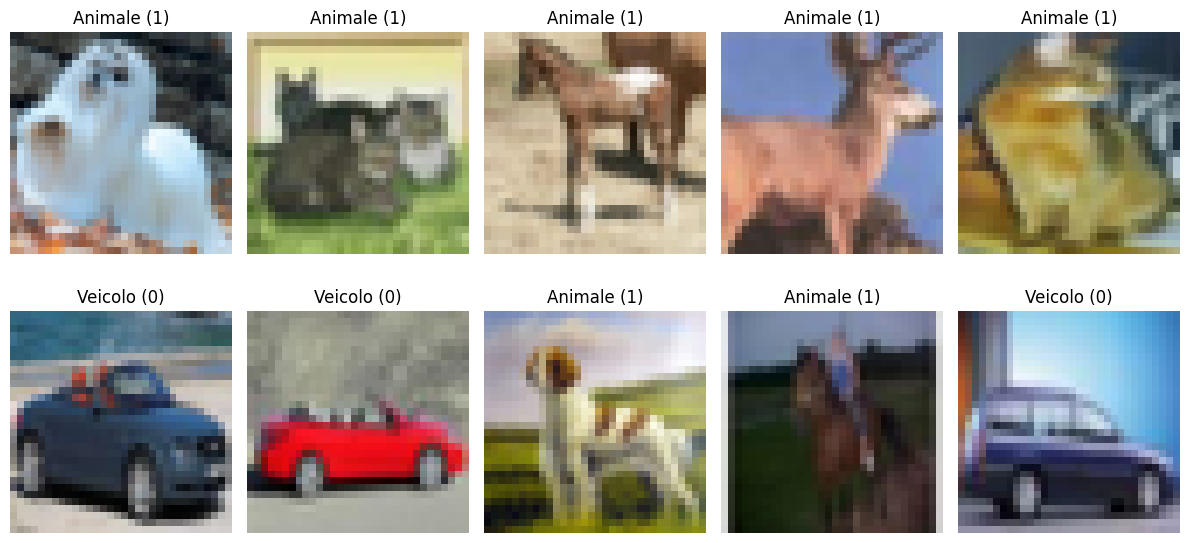

In [9]:
print("--- Verifico il set di TRAINING ---")
show_associates(x_train_bin, y_train_bin)

--- Verifico il set di TEST ---


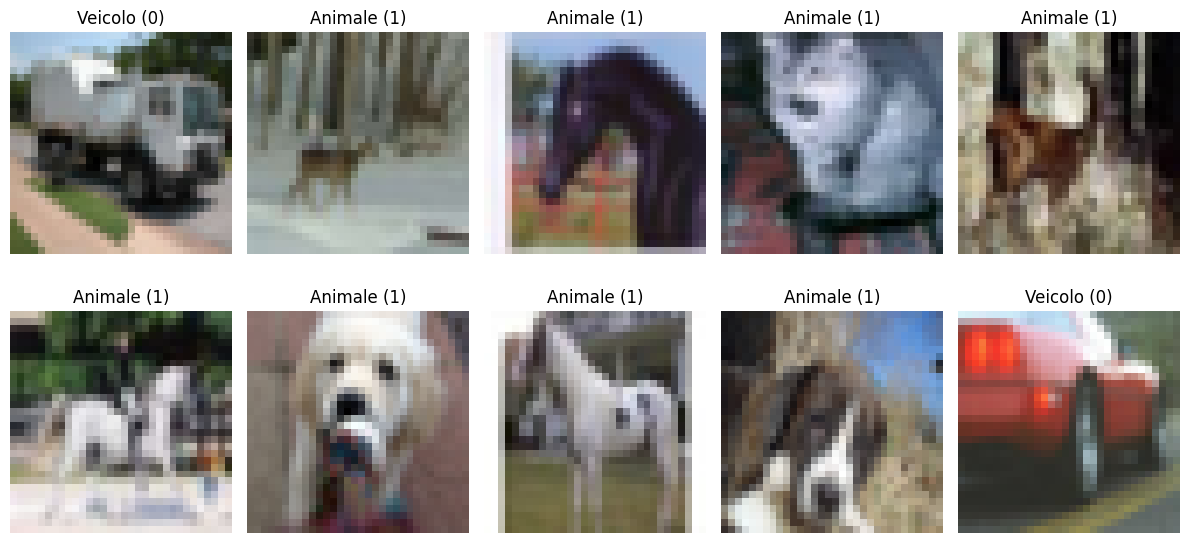

In [10]:
print("--- Verifico il set di TEST ---")
show_associates(x_test_bin, y_test_bin)

## DEFINIZIONE MODELLO

Dopo un'analisi degli iperparametri definiti nel file my_model.py, si effettua il compile con optimizer Adam (learning rate di partenza 0.001, successivamente modificato con ReduceLROnPlateau) e il calcolo delle varie metriche

In [11]:
# Inizializzo il modello:
model = cnn_model()

# Compilo:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

## ADDESTRAMENTO DEL MODELLO

Viene effettuato un addestramento su 50 epoche con Early Stopping implementato (definito nel file utils.py), batch size di 64 perchè avendo un dataset di migliaia di immagini risulta meglio per la batch normalization. L'uso del class_weight equilibria il set che è sbilanciato verso una delle due classi

In [ ]:
# Eseguo l'addestramento del modello:

history = model.fit(
    x_train_bin, y_train_bin,
    epochs=50,
    batch_size=64,
    validation_data=(x_test_bin, y_test_bin),
    class_weight={0: 2.0, 1: 1.0},    # Uso il bilanciamento dei pesi per equilibrare ulteriormente le classi
    callbacks=callbacks()
)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.8740 - loss: 0.3970 - precision: 0.9355 - recall: 0.8711 - val_accuracy: 0.8172 - val_loss: 0.3972 - val_precision: 0.9424 - val_recall: 0.7730 - learning_rate: 0.0010
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.9127 - loss: 0.2861 - precision: 0.9534 - recall: 0.9138 - val_accuracy: 0.8655 - val_loss: 0.3446 - val_precision: 0.9896 - val_recall: 0.8067 - learning_rate: 0.0010
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9297 - loss: 0.2498 - precision: 0.9594 - recall: 0.9341 - val_accuracy: 0.8240 - val_loss: 0.5393 - val_precision: 0.9940 - val_recall: 0.7405 - learning_rate: 0.0010
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.9327 - loss: 0.2309 - precision: 0.9620 - recall: 0.9360 - val_accuracy: 0.9387 - val_loss: 0.1756 - val_precision: 0.9776 - val_recall: 0.9293 - learning_rate: 0.0010
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - 

## SALVATAGGIO PESI

Visto che il modello ha ottenuto i risultati molto performanti (il risultato migliore all'epoca 44 con val_accuracy di 0.9645 e val_loss di 0.1224) salvo i pesi e la history del modello nella cartella models_saved

In [ ]:
# Salvo i pesi e la history del modello:

import pickle

save_path = "models_saved"
model.save_weights(os.path.join(save_path, "pesi_modello.weights.h5"))

with open(os.path.join(save_path, "modello_cnn_history.pkl"), "wb") as f:
  pickle.dump(history.history, f)

print("Pesi e history salvati correttamente")

Pesi e history salvati correttamente


In [15]:
# Carico i pesi del modello:

import pickle

model.load_weights("/content/drive/MyDrive/VisionTech_Project/models_saved/pesi_modello.weights.h5")
history_data = pickle.load(open("/content/drive/MyDrive/VisionTech_Project/models_saved/modello_cnn_history.pkl", "rb"))

In [17]:
# Valutazione finale del modello caricato
metrics = model.evaluate(x_test_bin, y_test_bin, verbose=2)

test_loss = metrics[0]
test_acc = metrics[1]
test_precision = metrics[2]
test_recall = metrics[3]

print(f'\n--- Risultati Finali ---')
print(f'Accuratezza: {test_acc*100:.2f}%')
print(f'Precisione:  {test_precision*100:.2f}%')
print(f'Recall:      {test_recall*100:.2f}%')


188/188 - 12s - 66ms/step - accuracy: 0.9645 - loss: 0.1224 - precision: 0.9907 - recall: 0.9557

--- Risultati Finali ---
Accuratezza: 96.45%
Precisione:  99.07%
Recall:      95.57%


## VISUALIZZAZIONE GRAFICI

Il primo grafico rappresenta l'andamento della loss ed accuracy nelle varie epoche dove si vede che l'overfitting è pressochè assente (le linee convergono insieme e non prendono direzioni diverse) e, grazie alla riduzione del learning rate, le curve che prima sobbalzavano si sono stabilizzate intorno all'epoca 35. Il grafico dimostra anche che 50 epoche sono stati sufficienti perchè il modello non avrebbe potuto imparare tanto di più (curve che hanno raggiunto il plateau)

Nella matrice di confusione e nel classification report, invece, si vede che il modello ha una precisione di 0.99 sugli animali e una recall di 0.98 su veicoli. Probabilmente il modello confonde un animale per un veicolo, ma con immagini a bassa risoluzione (32x32px) certe forme sono facili da confondere

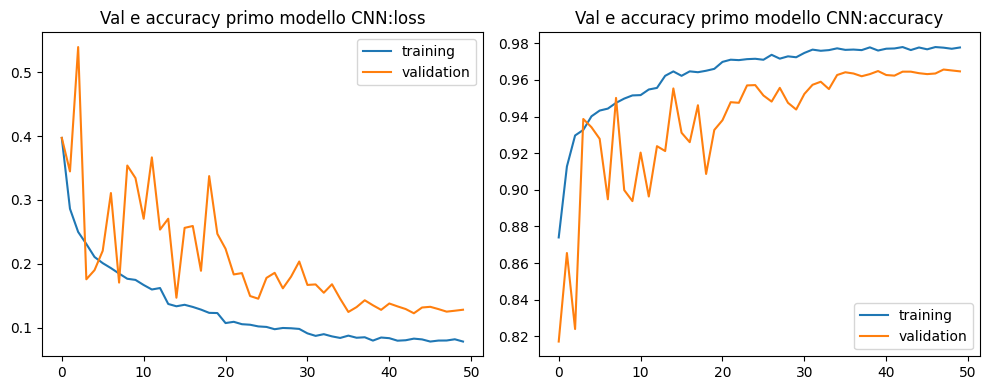

In [ ]:
# Visualizzo il grafico della loss e accuracy per il modello addestrato in precedenza:

plot_learning_curves(history, "Val e accuracy primo modello CNN")

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


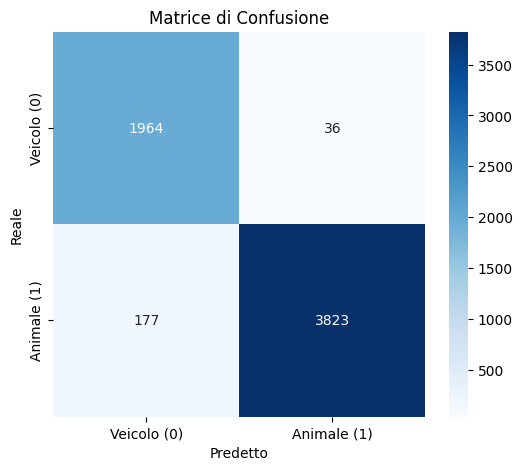

              precision    recall  f1-score   support

     Veicolo       0.92      0.98      0.95      2000
     Animale       0.99      0.96      0.97      4000

    accuracy                           0.96      6000
   macro avg       0.95      0.97      0.96      6000
weighted avg       0.97      0.96      0.96      6000



In [ ]:
# Vedo la matrice di confusione:

# Ottengo le predizioni (probabilità):
y_pred_probs = model.predict(x_test_bin)

# Converto le probabilità in classi (0 o 1) usando la soglia 0.5:
y_pred = (y_pred_probs > 0.5).astype(int)

# Genero la matrice
cm = confusion_matrix(y_test_bin, y_pred)

# Visualizzazione grafica
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Veicolo (0)", "Animale (1)"],
            yticklabels=["Veicolo (0)", "Animale (1)"])
plt.xlabel("Predetto")
plt.ylabel("Reale")
plt.title("Matrice di Confusione")
plt.show()

# Stampo il report testuale (Precision, Recall, F1-Score)
print(classification_report(y_test_bin, y_pred, target_names=["Veicolo", "Animale"]))

## ESAME DELLE IMMAGINI ERRATE

Nel plot sottostante prendo 20 immagini per vedere dove il modello ha sbagliato.

Su 20 immagini in questione il modello ha sbagliato di classificare il cavallo come animale: si può pensare che il muso del cavallo ha fatto pensare al modello che fosse la sagoma di un automobile (tipo quella della seconda immagine)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


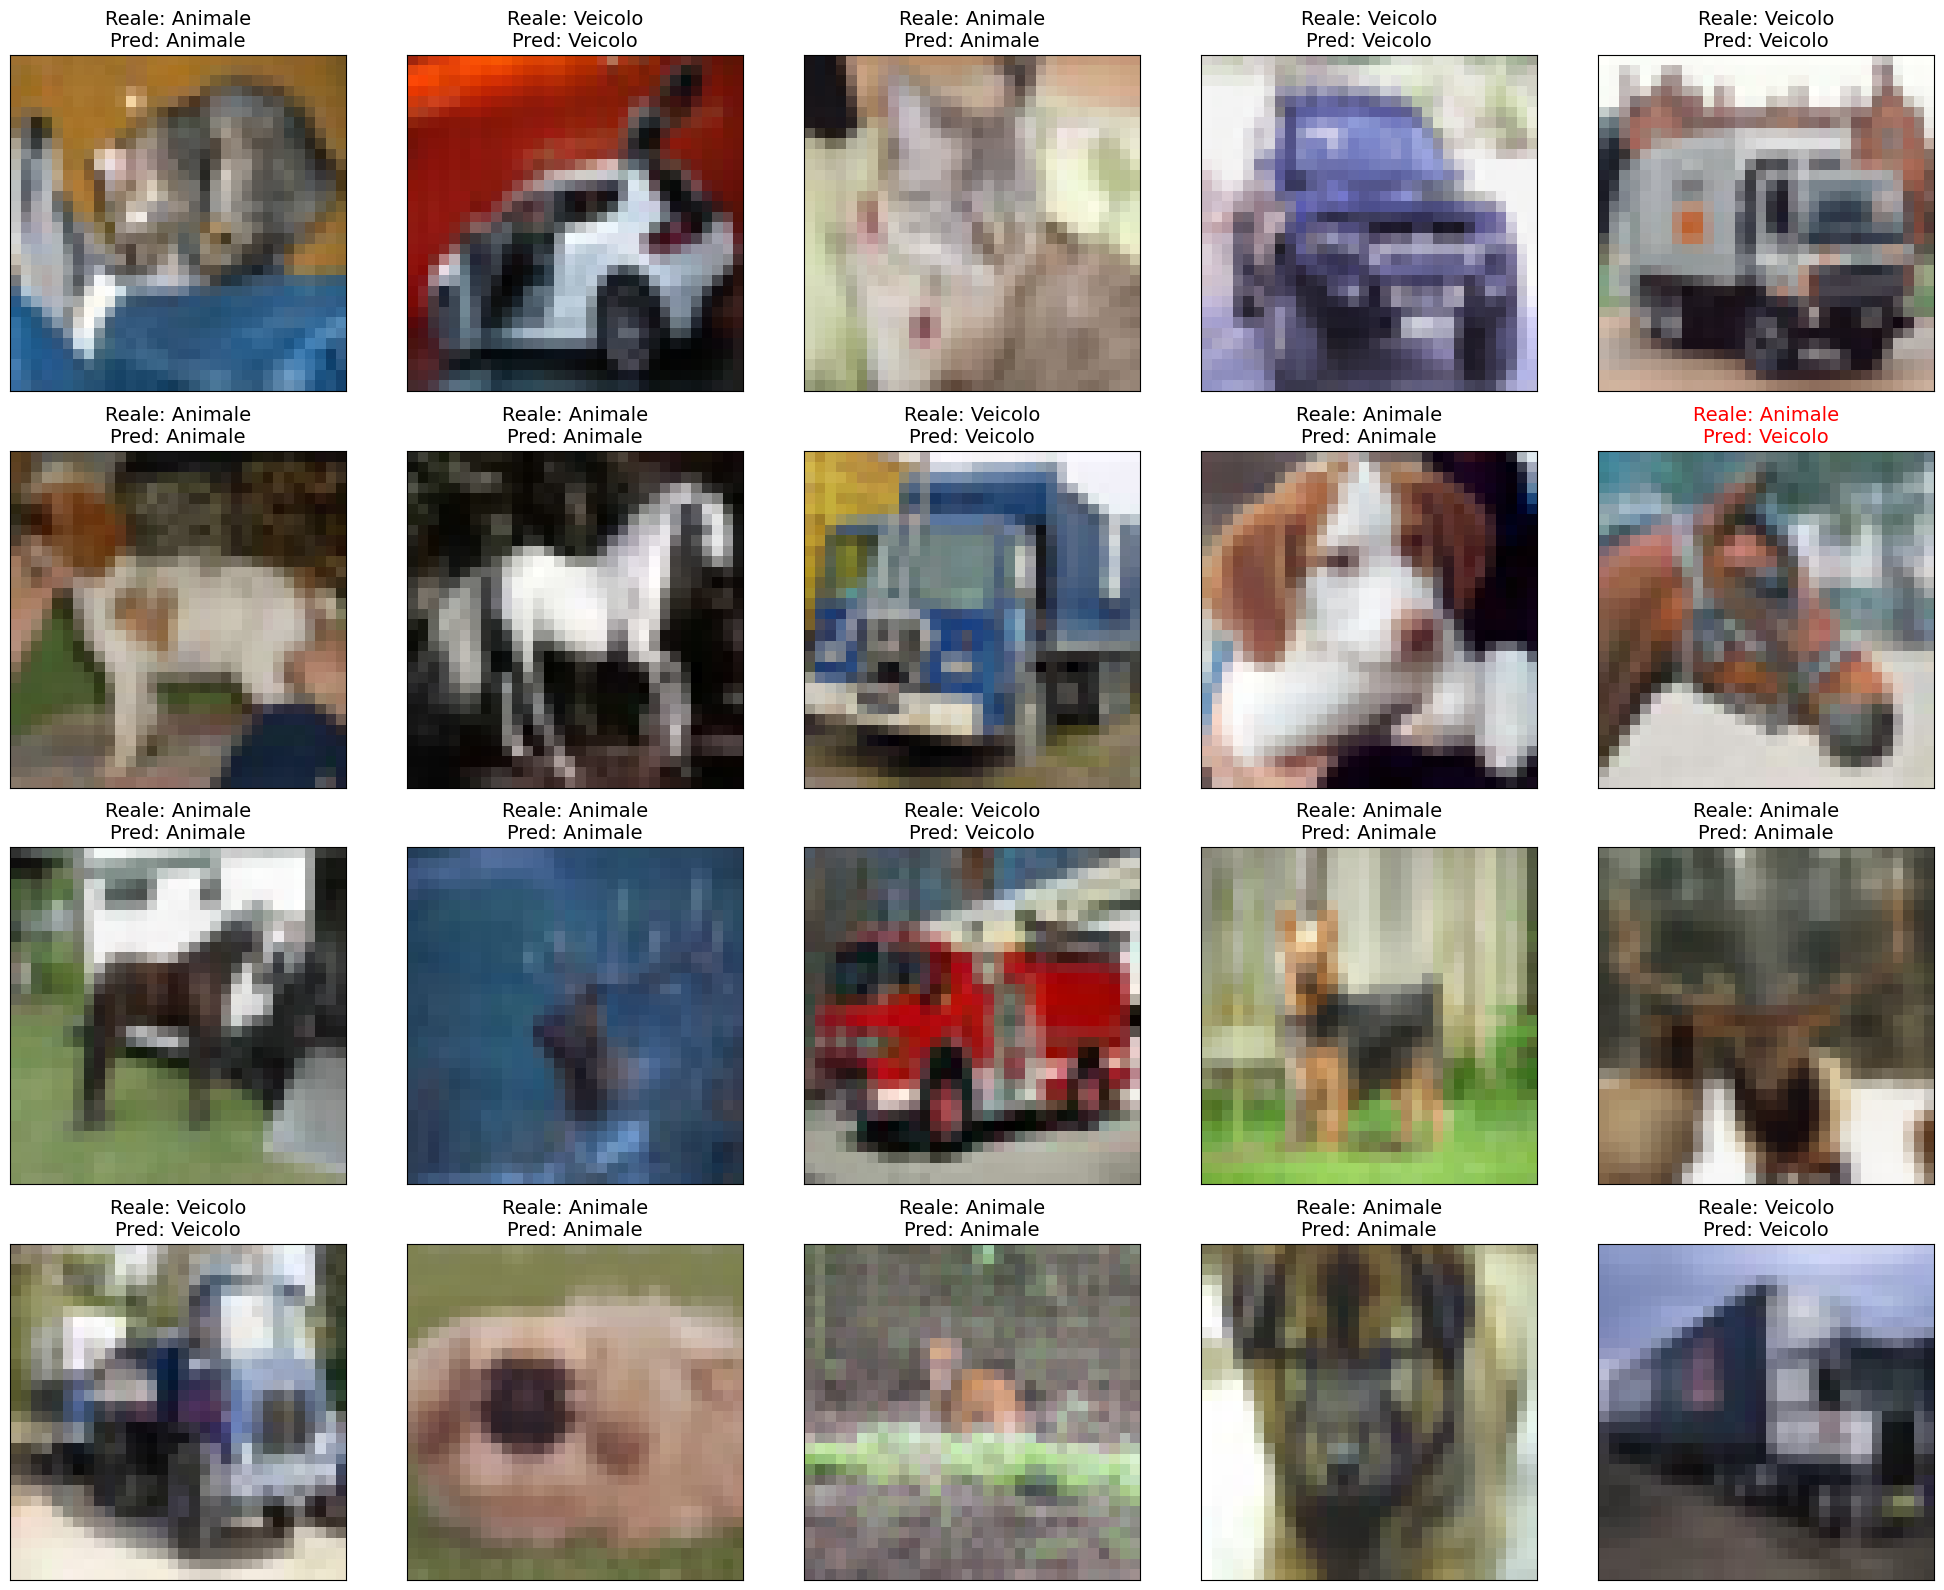

In [ ]:
# Ottengo le predictions:

predictions = model.predict(x_test_bin)

# Mappo i risultati:

string_predictions = np.where(predictions.flatten() > 0.5, 'Animale', 'Veicolo')
class_names = ['Veicolo', 'Animale']

plt.figure(figsize=(20, 16))

for k in range(20):
    plt.subplot(4, 5, k + 1)
    # Mostro l'immagine originale:
    plt.imshow(x_test_bin[k])
    # Ottengo l'etichetta reale:
    real_idx = int(y_test_bin[k].item())
    real_label = class_names[real_idx]
    # Imposto i colori (nero -- corretto, rosso -- sbagliato):
    is_correct = real_label == string_predictions[k]
    plt.title(f"Reale: {real_label}\nPred: {string_predictions[k]}",
              fontsize=14,
              color='black' if is_correct else 'red')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

## VISUALIZZAZIONE UI CON GRADIO

Come interfaccia per il modello ho scelto gradio che permette di caricare un immagine e il modello implementato restituisce il risultato dell'analisi in base al pericolo (animale = pericolo)

In [ ]:
def visiontech_classifier(input_img):
    # Ridimensiono a 32x32 e normalizzo:
    img = tf.image.resize(input_img, (32, 32))
    img = img / 255.0
    img = tf.expand_dims(img, axis=0) # Aggiunge la dimensione del batch (1, 32, 32, 3)

    # Predizione
    prediction = model.predict(img)[0][0]

    # 3. Formattazione output per Gradio:
    prob_animale = float(prediction)
    prob_veicolo = 1.0 - prob_animale

    return {
        "Veicolo (Prestare attenzione)": prob_veicolo,
        "Animale (Pericolo)": prob_animale
    }

# Creazione dell'interfaccia:
demo = gr.Interface(
    fn=visiontech_classifier,
    inputs=gr.Image(label="Carica immagine strada"),
    outputs=gr.Label(num_top_classes=2, label="Analisi AI"),
    title="VisionTech",
    description="Sistema di rilevamento ostacoli intelligente",
    examples=["auto.jpg", "cane.jpg"],
    theme="soft"
)

# Lancio:
demo.launch(share=True) # share=True genera il link